In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Setting style
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

# Load data
df = pd.read_csv('../data/cleaned/cleaned_data.csv')
df_cancelled = pd.read_csv('../data/cleaned/cancelled_transactions.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"df shape: {df.shape}")
print(f"df_cancelled shape: {df_cancelled.shape}")
df.head()

✅ df shape: (779425, 12)
✅ df_cancelled shape: (19494, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Year,Month,DayOfWeek
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,Tuesday


# Revenue Analysis

In [23]:
# Hitung KPI utama
total_revenue = df['TotalPrice'].sum()
total_orders = df['Invoice'].nunique()
total_customers = df['Customer ID'].nunique()
total_products = df['StockCode'].nunique()
aov = total_revenue / total_orders

print("=" * 45)
print("KPI SUMMARY")
print("=" * 45)
print(f"Total Revenue    : £{total_revenue:,.2f}")
print(f"Total Orders     : {total_orders:,}")
print(f"Total Customers  : {total_customers:,}")
print(f"Total Products   : {total_products:,}")
print(f"AOV              : £{aov:,.2f}")
print("=" * 45)

KPI SUMMARY
Total Revenue    : £17,374,804.27
Total Orders     : 36,969
Total Customers  : 5,878
Total Products   : 4,631
AOV              : £469.98


In [24]:
# Hitung revenue bulanan dan growth MoM
monthly = df.groupby(['Year', 'Month']).agg(
    Monthly_Revenue  = ('TotalPrice', 'sum'),
    Total_Orders     = ('Invoice', 'nunique'),
    Total_Customers  = ('Customer ID', 'nunique')
).reset_index()

monthly['YearMonth'] = pd.to_datetime(
    monthly[['Year', 'Month']].assign(day=1)
)
monthly['MoM_Growth'] = monthly['Monthly_Revenue'].pct_change() * 100
monthly['MoM_Growth'] = monthly['MoM_Growth'].round(2)

print(monthly[['YearMonth', 'Monthly_Revenue', 
               'Total_Orders', 'MoM_Growth']].to_string(index=False))

 YearMonth  Monthly_Revenue  Total_Orders  MoM_Growth
2009-12-01       683504.010          1512         NaN
2010-01-01       555802.672          1011      -18.68
2010-02-01       504558.956          1104       -9.22
2010-03-01       696978.471          1524       38.14
2010-04-01       591982.002          1329      -15.06
2010-05-01       597833.380          1377        0.99
2010-06-01       636371.130          1497        6.45
2010-07-01       589736.170          1381       -7.33
2010-08-01       602224.600          1293        2.12
2010-09-01       829013.951          1689       37.66
2010-10-01      1033112.010          2133       24.62
2010-11-01      1166460.022          2587       12.91
2010-12-01       570422.730          1400      -51.10
2011-01-01       568101.310           987       -0.41
2011-02-01       446084.920           997      -21.48
2011-03-01       594081.760          1321       33.18
2011-04-01       468374.331          1149      -21.16
2011-05-01       677355.150 

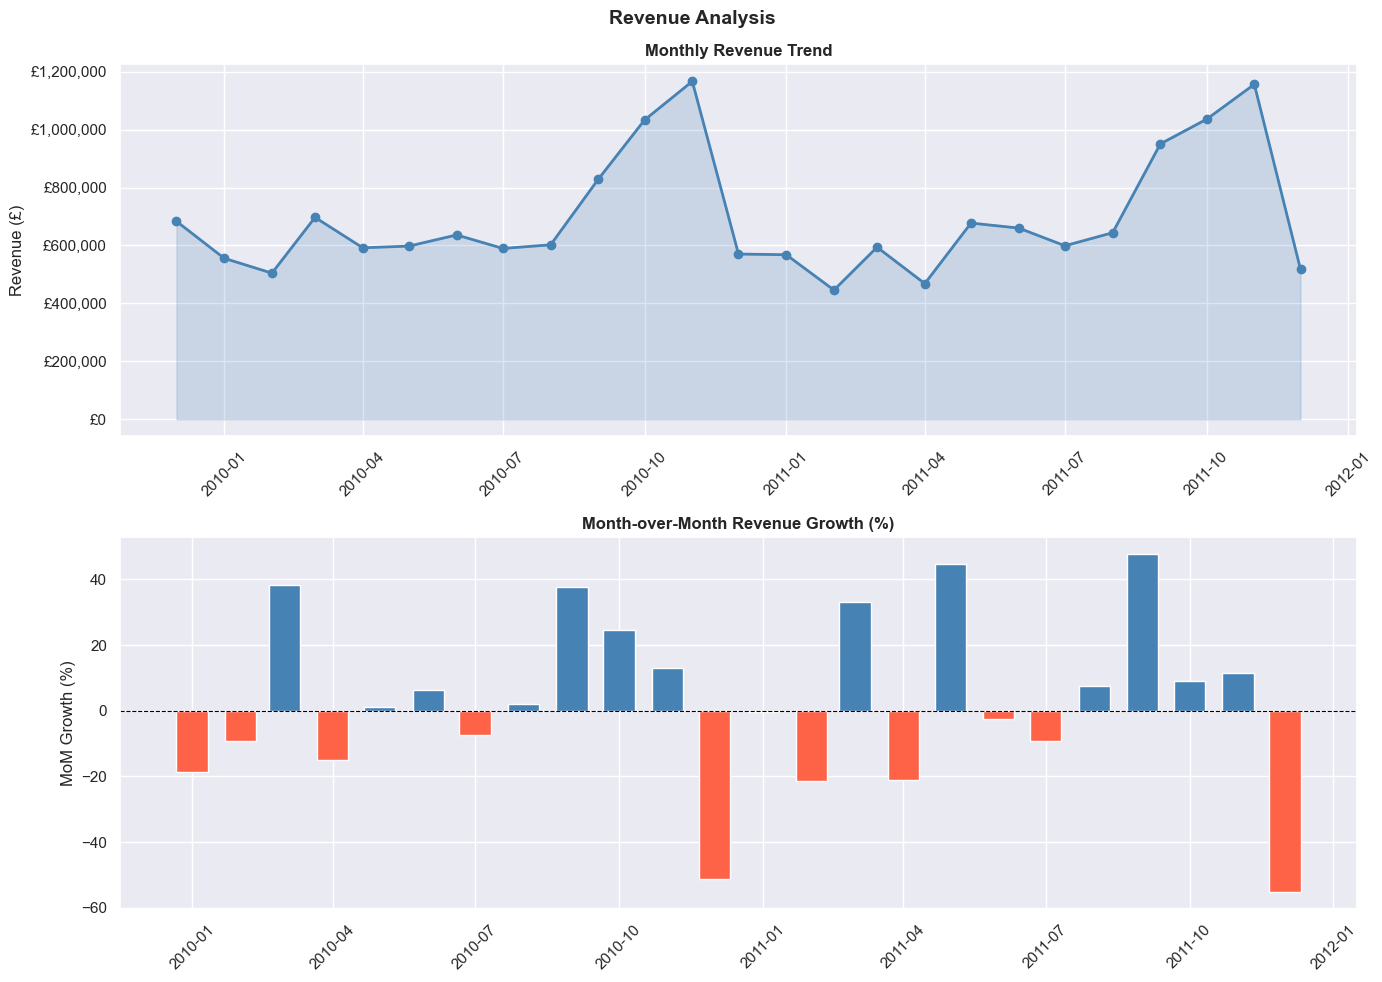

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Monthly Revenue
axes[0].plot(monthly['YearMonth'], monthly['Monthly_Revenue'],
             marker='o', color='steelblue', linewidth=2)
axes[0].fill_between(monthly['YearMonth'], 
                     monthly['Monthly_Revenue'], 
                     alpha=0.2, color='steelblue')
axes[0].set_title('Monthly Revenue Trend', fontweight='bold')
axes[0].set_ylabel('Revenue (£)')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: MoM Growth
colors = ['tomato' if x < 0 else 'steelblue' 
          for x in monthly['MoM_Growth'].fillna(0)]
axes[1].bar(monthly['YearMonth'], monthly['MoM_Growth'],
            color=colors, width=20)
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Month-over-Month Revenue Growth (%)', fontweight='bold')
axes[1].set_ylabel('MoM Growth (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Revenue Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/13_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

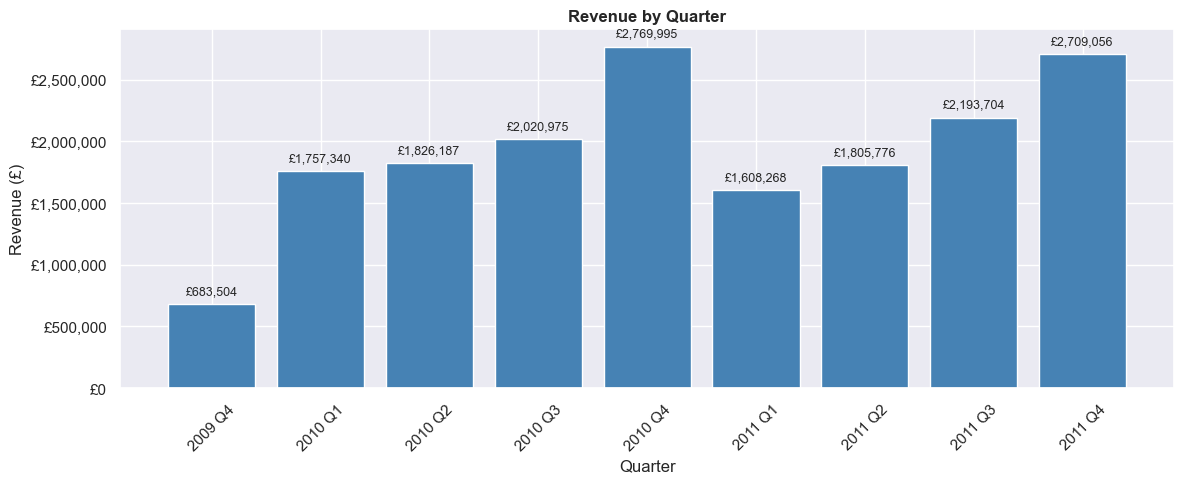

In [26]:
# Revenue per quarter
df['Quarter'] = df['InvoiceDate'].dt.quarter
quarterly = df.groupby(['Year', 'Quarter']).agg(
    Quarterly_Revenue = ('TotalPrice', 'sum'),
    Total_Orders      = ('Invoice', 'nunique')
).reset_index()
quarterly['YearQuarter'] = (quarterly['Year'].astype(str) + 
                             ' Q' + quarterly['Quarter'].astype(str))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(quarterly['YearQuarter'], 
              quarterly['Quarterly_Revenue'], color='steelblue')
ax.bar_label(bars, fmt='£{:,.0f}', padding=5, fontsize=9)
ax.set_title('Revenue by Quarter', fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/14_revenue_by_quarter.png', dpi=150, bbox_inches='tight')
plt.show()

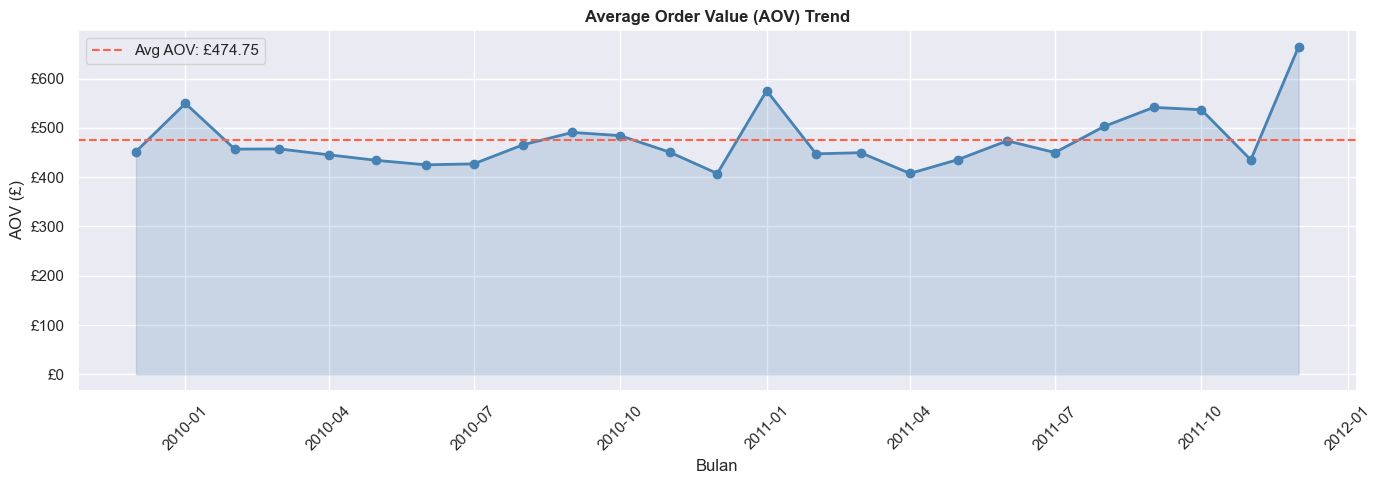

In [27]:
# Visualisasi tren AOV
monthly['AOV'] = monthly['Monthly_Revenue'] / monthly['Total_Orders']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['YearMonth'], monthly['AOV'],
        marker='o', color='steelblue', linewidth=2)
ax.fill_between(monthly['YearMonth'], monthly['AOV'],
                alpha=0.2, color='steelblue')
ax.axhline(y=monthly['AOV'].mean(), color='tomato', 
           linewidth=1.5, linestyle='--',
           label=f"Avg AOV: £{monthly['AOV'].mean():,.2f}")
ax.set_title('Average Order Value (AOV) Trend', fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('AOV (£)')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/15_aov_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Simpan monthly revenue
monthly.to_csv('../data/cleaned/monthly_revenue.csv', index=False)

# Simpan quarterly revenue
quarterly.to_csv('../data/cleaned/quarterly_revenue.csv', index=False)

# Simpan KPI summary (update dengan AOV dari monthly)
kpi_summary = pd.DataFrame([{
    'Total_Revenue'   : round(total_revenue, 2),
    'Total_Orders'    : total_orders,
    'Total_Customers' : total_customers,
    'Total_Products'  : total_products,
    'AOV'             : round(aov, 2)
}])
kpi_summary.to_csv('../data/cleaned/kpi_summary.csv', index=False)

print("monthly_revenue.csv berhasil disimpan!")
print("quarterly_revenue.csv berhasil disimpan!")
print("kpi_summary.csv berhasil disimpan!")
print(f"\nFile tersimpan di data/cleaned/:")
print(f"monthly_revenue.csv → {len(monthly)} baris")
print(f"quarterly_revenue.csv → {len(quarterly)} baris")
print(f"kpi_summary.csv → 1 baris (KPI keseluruhan)")

✅ monthly_revenue.csv berhasil disimpan!
✅ quarterly_revenue.csv berhasil disimpan!
✅ kpi_summary.csv berhasil disimpan!

File tersimpan di data/cleaned/:
monthly_revenue.csv → 25 baris
quarterly_revenue.csv → 9 baris
kpi_summary.csv → 1 baris (KPI keseluruhan)


# Product Analysis

In [36]:
# Agregasi per produk
product_analysis = df.groupby(['StockCode', 'Description']).agg(
    Total_Quantity = ('Quantity', 'sum'),
    Total_Revenue  = ('TotalPrice', 'sum'),
    Total_Orders   = ('Invoice', 'nunique')
).reset_index()
product_analysis['Avg_Price'] = (product_analysis['Total_Revenue'] / 
                                  product_analysis['Total_Quantity']).round(2)

# Filter non-produk
non_products = ['POSTAGE', 'Manual', 'DOTCOM POSTAGE',
                'Adjust bad debt', 'CRUK Commission']
product_analysis = product_analysis[
    (~product_analysis['Description'].isin(non_products)) &
    (product_analysis['StockCode'].str.match(r'^\d{5}'))
]

product_analysis = product_analysis.sort_values('Total_Revenue', ascending=False)

print(f"Total produk (setelah filter): {len(product_analysis):,}")

# Top 10 by Revenue
top10_revenue = product_analysis.head(10)

# Bottom 10 by Revenue (min 10 orders agar representatif)
bottom10_revenue = (product_analysis[product_analysis['Total_Orders'] >= 10]
                    .tail(10))

print("\nTop 10 Products by Revenue:")
print(top10_revenue[['Description', 'Total_Quantity',
                      'Total_Revenue', 'Total_Orders']].to_string(index=False))
print("\nBottom 10 Products by Revenue (min 10 orders):")
print(bottom10_revenue[['Description', 'Total_Quantity',
                         'Total_Revenue', 'Total_Orders']].to_string(index=False))

Total produk (setelah filter): 5,301

Top 10 Products by Revenue:
                       Description  Total_Quantity  Total_Revenue  Total_Orders
          REGENCY CAKESTAND 3 TIER           24124      277656.25          3317
WHITE HANGING HEART T-LIGHT HOLDER           91757      247048.01          4888
       PAPER CRAFT , LITTLE BIRDIE           80995      168469.60             1
           JUMBO BAG RED RETROSPOT           74224      134307.44          2612
     ASSORTED COLOUR BIRD ORNAMENT           78234      124351.86          2652
                     PARTY BUNTING           23460      103283.38          2077
    MEDIUM CERAMIC TOP STORAGE JAR           77916       81416.73           195
   PAPER CHAIN KIT 50'S CHRISTMAS            28380       76598.18          1691
                     CHILLI LIGHTS           14843       69084.30           922
              JUMBO BAG STRAWBERRY           35842       64127.77          1514

Bottom 10 Products by Revenue (min 10 orders):
      

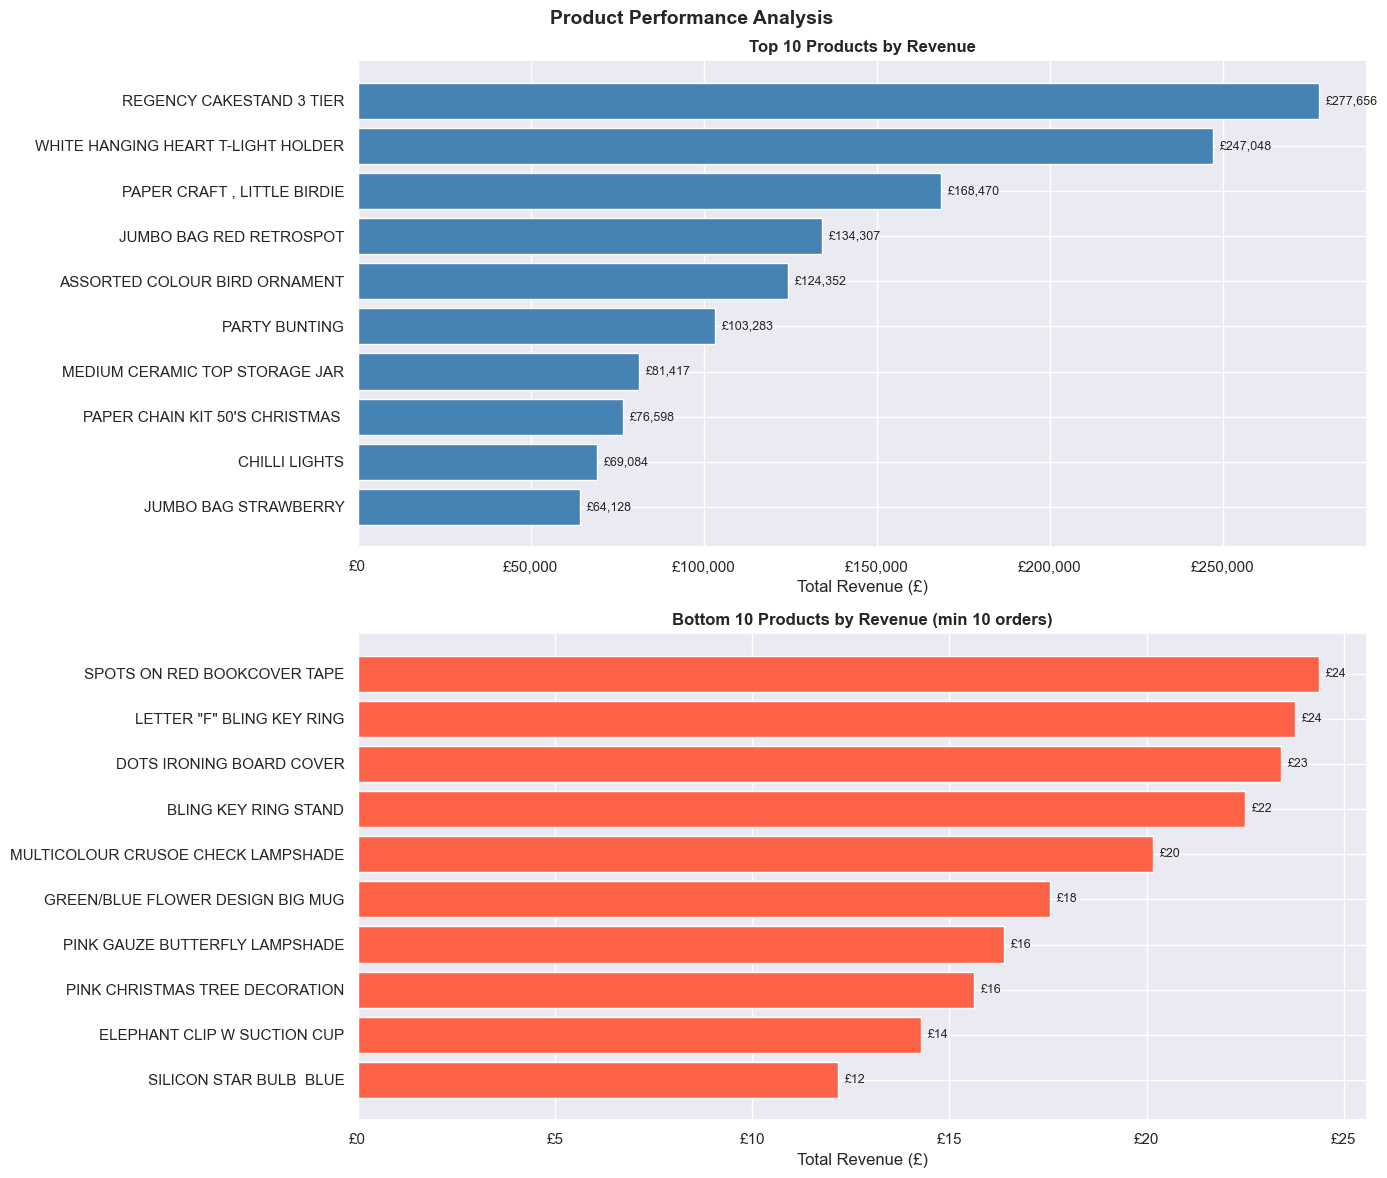

In [37]:
# Visualisasi produk terbaik dan terburuk
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Top 10
bars = axes[0].barh(top10_revenue['Description'], 
                    top10_revenue['Total_Revenue'], color='steelblue')
axes[0].bar_label(bars, fmt='£{:,.0f}', padding=5, fontsize=9)
axes[0].set_title('Top 10 Products by Revenue', fontweight='bold')
axes[0].set_xlabel('Total Revenue (£)')
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

# Bottom 10
bars = axes[1].barh(bottom10_revenue['Description'],
                    bottom10_revenue['Total_Revenue'], color='tomato')
axes[1].bar_label(bars, fmt='£{:,.0f}', padding=5, fontsize=9)
axes[1].set_title('Bottom 10 Products by Revenue (min 10 orders)', 
                   fontweight='bold')
axes[1].set_xlabel('Total Revenue (£)')
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

plt.suptitle('Product Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/16_product_performance.png', dpi=150, bbox_inches='tight')
plt.show()

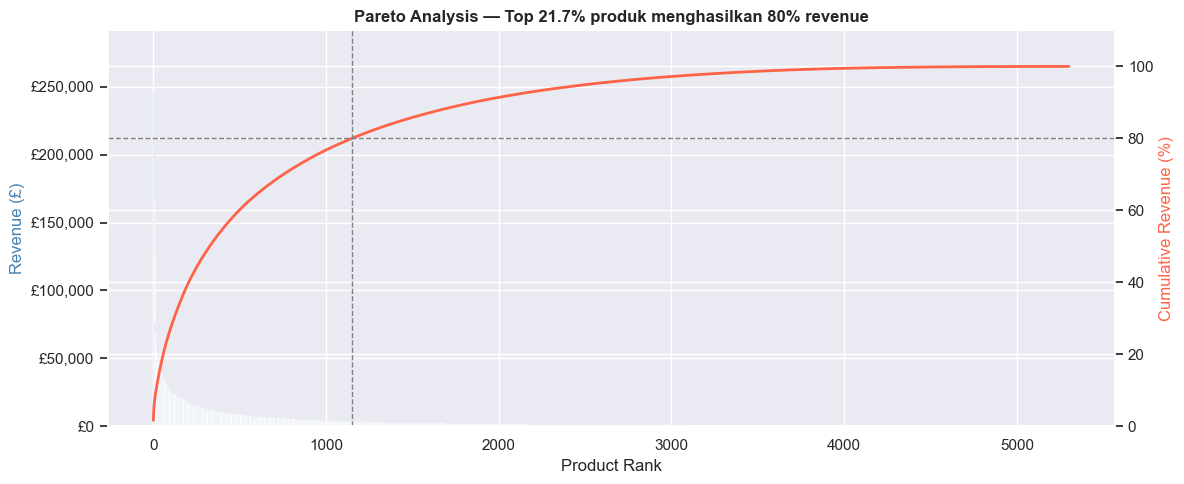

Top 1150 produk (21.7%) menghasilkan 80% dari total revenue


In [38]:
# Hitung kumulatif revenue
product_sorted = product_analysis.sort_values('Total_Revenue', ascending=False)
product_sorted['Cumulative_Revenue'] = product_sorted['Total_Revenue'].cumsum()
product_sorted['Cumulative_Pct'] = (product_sorted['Cumulative_Revenue'] / 
                                     product_sorted['Total_Revenue'].sum() * 100)
product_sorted['Product_Rank'] = range(1, len(product_sorted) + 1)
product_sorted['Product_Pct'] = (product_sorted['Product_Rank'] / 
                                  len(product_sorted) * 100)

# Cari berapa % produk yang menghasilkan 80% revenue
pct_80 = product_sorted[product_sorted['Cumulative_Pct'] <= 80].shape[0]
pct_products = round(pct_80 / len(product_sorted) * 100, 1)

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(product_sorted['Product_Rank'], 
        product_sorted['Total_Revenue'],
        color='steelblue', alpha=0.6, label='Revenue per Product')
ax1.set_xlabel('Product Rank')
ax1.set_ylabel('Revenue (£)', color='steelblue')
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

ax2 = ax1.twinx()
ax2.plot(product_sorted['Product_Rank'], 
         product_sorted['Cumulative_Pct'],
         color='tomato', linewidth=2, label='Cumulative Revenue %')
ax2.axhline(y=80, color='gray', linestyle='--', linewidth=1)
ax2.axvline(x=pct_80, color='gray', linestyle='--', linewidth=1)
ax2.set_ylabel('Cumulative Revenue (%)', color='tomato')
ax2.set_ylim(0, 110)

plt.title(f'Pareto Analysis — Top {pct_products}% produk menghasilkan 80% revenue',
          fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/17_pareto_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Top {pct_80} produk ({pct_products}%) menghasilkan 80% dari total revenue")

In [ ]:
# Simpan output product analysis
product_analysis.to_csv('../data/cleaned/product_analysis.csv', index=False)
print("product_analysis.csv berhasil disimpan!")
print(f"Total produk: {len(product_analysis):,}")

✅ product_analysis.csv berhasil disimpan!
Total produk: 5,301


# Cancellation Analysis

In [ ]:
# Load transaksi yg cancelled
df_cancelled['InvoiceDate'] = pd.to_datetime(df_cancelled['InvoiceDate'])
df_cancelled['Year']  = df_cancelled['InvoiceDate'].dt.year
df_cancelled['Month'] = df_cancelled['InvoiceDate'].dt.month
df_cancelled['YearMonth'] = pd.to_datetime(
    df_cancelled[['Year', 'Month']].assign(day=1)
)

# Total cancelled value (absolute)
df_cancelled['TotalPrice'] = (df_cancelled['Quantity'].abs() * 
                               df_cancelled['Price'])

print(f"Total cancelled transactions : {len(df_cancelled):,}")
print(f"Total cancelled orders       : {df_cancelled['Invoice'].nunique():,}")
print(f"Total cancelled value        : £{df_cancelled['TotalPrice'].sum():,.2f}")
print(f"Unique customers cancelled   : {df_cancelled['Customer ID'].nunique():,}")

Total cancelled transactions : 19,494
Total cancelled orders       : 8,292
Total cancelled value        : £1,527,415.00
Unique customers cancelled   : 2,572


In [ ]:
# Summary transaksi cancelled
total_orders_all = df['Invoice'].nunique() + df_cancelled['Invoice'].nunique()
cancel_rate = df_cancelled['Invoice'].nunique() / total_orders_all * 100

total_revenue_all = df['TotalPrice'].sum() + df_cancelled['TotalPrice'].sum()
cancel_revenue_pct = df_cancelled['TotalPrice'].sum() / total_revenue_all * 100

print("=" * 45)
print("CANCELLATION SUMMARY")
print("=" * 45)
print(f"Total Orders (incl. cancelled) : {total_orders_all:,}")
print(f"Cancelled Orders               : {df_cancelled['Invoice'].nunique():,}")
print(f"Cancellation Rate (orders)     : {cancel_rate:.2f}%")
print(f"Cancelled Revenue Value        : £{df_cancelled['TotalPrice'].sum():,.2f}")
print(f"Cancellation Rate (revenue)    : {cancel_revenue_pct:.2f}%")
print("=" * 45)

CANCELLATION SUMMARY
Total Orders (incl. cancelled) : 45,261
Cancelled Orders               : 8,292
Cancellation Rate (orders)     : 18.32%
Cancelled Revenue Value        : £1,527,415.00
Cancellation Rate (revenue)    : 8.08%


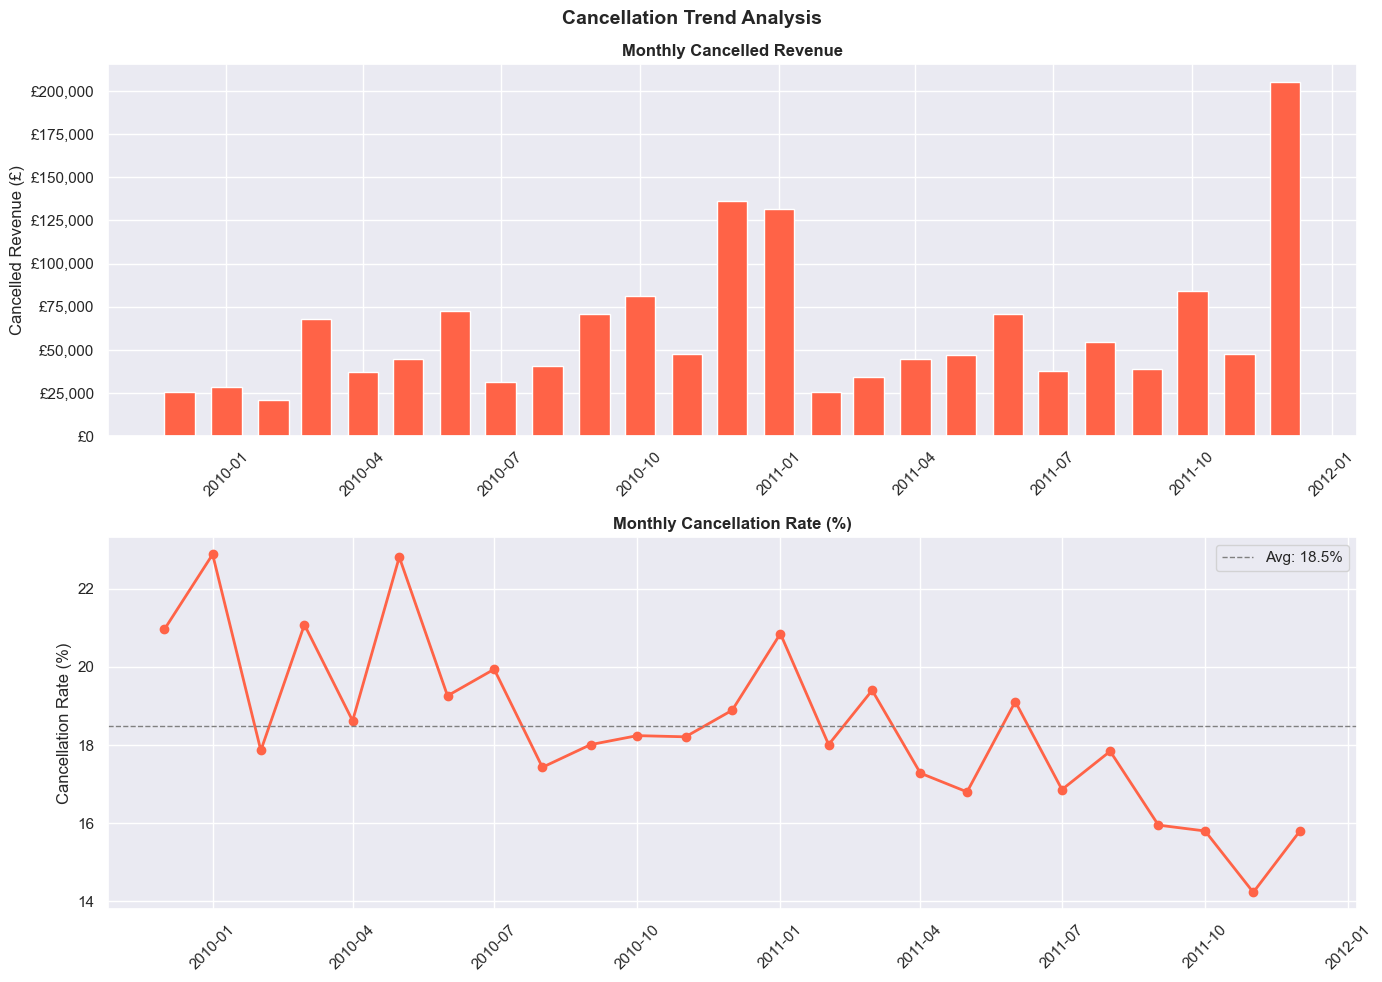

In [45]:
# Trend cancellation per bulan
monthly_cancel = df_cancelled.groupby('YearMonth').agg(
    Cancelled_Orders  = ('Invoice', 'nunique'),
    Cancelled_Revenue = ('TotalPrice', 'sum')
).reset_index()

# Gabungkan dengan monthly revenue untuk hitung rate
monthly_cancel = monthly_cancel.merge(
    monthly[['YearMonth', 'Total_Orders', 'Monthly_Revenue']],
    on='YearMonth', how='left'
)
monthly_cancel['Cancel_Rate'] = (
    monthly_cancel['Cancelled_Orders'] /
    (monthly_cancel['Total_Orders'] + monthly_cancel['Cancelled_Orders']) * 100
).round(2)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Cancelled Revenue per bulan
axes[0].bar(monthly_cancel['YearMonth'], 
            monthly_cancel['Cancelled_Revenue'],
            color='tomato', width=20)
axes[0].set_title('Monthly Cancelled Revenue', fontweight='bold')
axes[0].set_ylabel('Cancelled Revenue (£)')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Cancellation Rate per bulan
axes[1].plot(monthly_cancel['YearMonth'], 
             monthly_cancel['Cancel_Rate'],
             marker='o', color='tomato', linewidth=2)
axes[1].axhline(y=monthly_cancel['Cancel_Rate'].mean(), 
                color='gray', linestyle='--', linewidth=1,
                label=f"Avg: {monthly_cancel['Cancel_Rate'].mean():.1f}%")
axes[1].set_title('Monthly Cancellation Rate (%)', fontweight='bold')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.suptitle('Cancellation Trend Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/18_cancellation_trend.png', dpi=150, bbox_inches='tight')
plt.show()

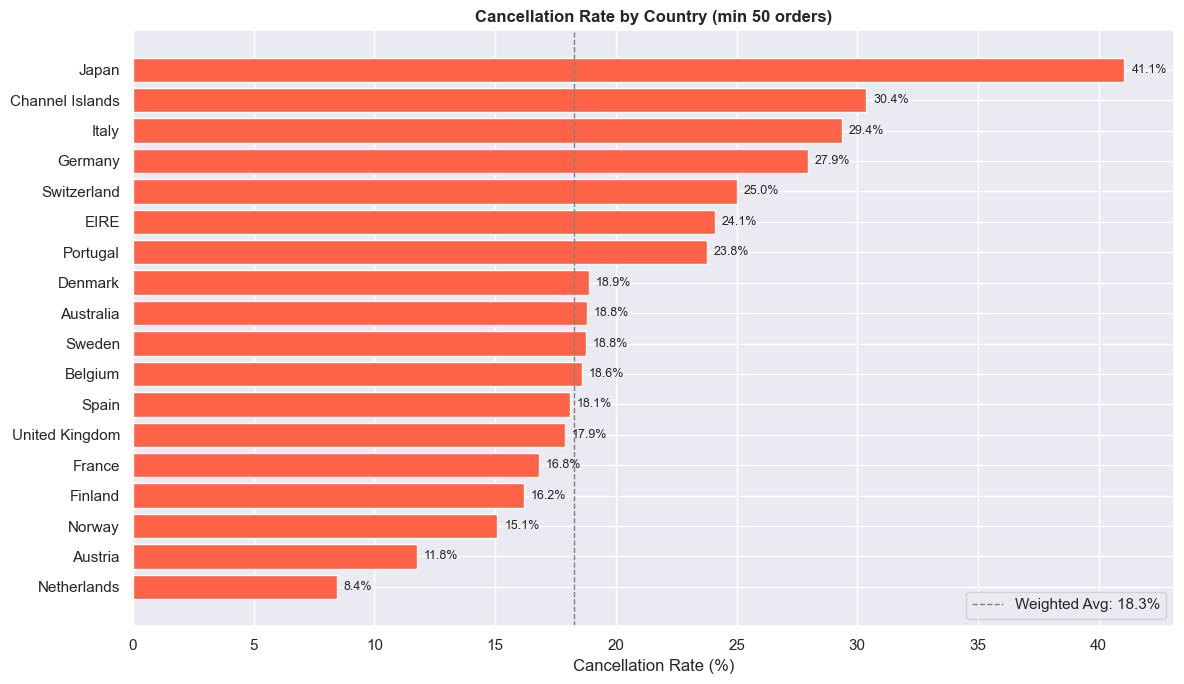

In [57]:
# Hitung per negara
cancel_by_country = df_cancelled.groupby('Country').agg(
    Cancelled_Orders = ('Invoice', 'nunique')
).reset_index()

normal_by_country = df.groupby('Country').agg(
    Normal_Orders = ('Invoice', 'nunique')
).reset_index()

country_cancel = cancel_by_country.merge(
    normal_by_country, on='Country', how='outer'
).fillna(0)
country_cancel['Total_Orders'] = (country_cancel['Cancelled_Orders'] + 
                                   country_cancel['Normal_Orders'])
country_cancel['Cancel_Rate'] = (
    country_cancel['Cancelled_Orders'] / 
    country_cancel['Total_Orders'] * 100
).round(2)

# Filter min 50 total orders agar representatif
country_cancel = country_cancel[
    country_cancel['Total_Orders'] >= 50
].sort_values('Cancel_Rate', ascending=False)

# Weighted average
weighted_avg = (
    (country_cancel['Cancelled_Orders'].sum() / 
     country_cancel['Total_Orders'].sum()) * 100
)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(country_cancel['Country'], 
               country_cancel['Cancel_Rate'],
               color='tomato')
ax.bar_label(bars, fmt='{:.1f}%', padding=5, fontsize=9)
ax.axvline(x=weighted_avg, 
           color='gray', linestyle='--', linewidth=1,
           label=f"Weighted Avg: {weighted_avg:.1f}%")
ax.set_title('Cancellation Rate by Country (min 50 orders)', 
             fontweight='bold')
ax.set_xlabel('Cancellation Rate (%)')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.savefig('../reports/19_cancellation_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

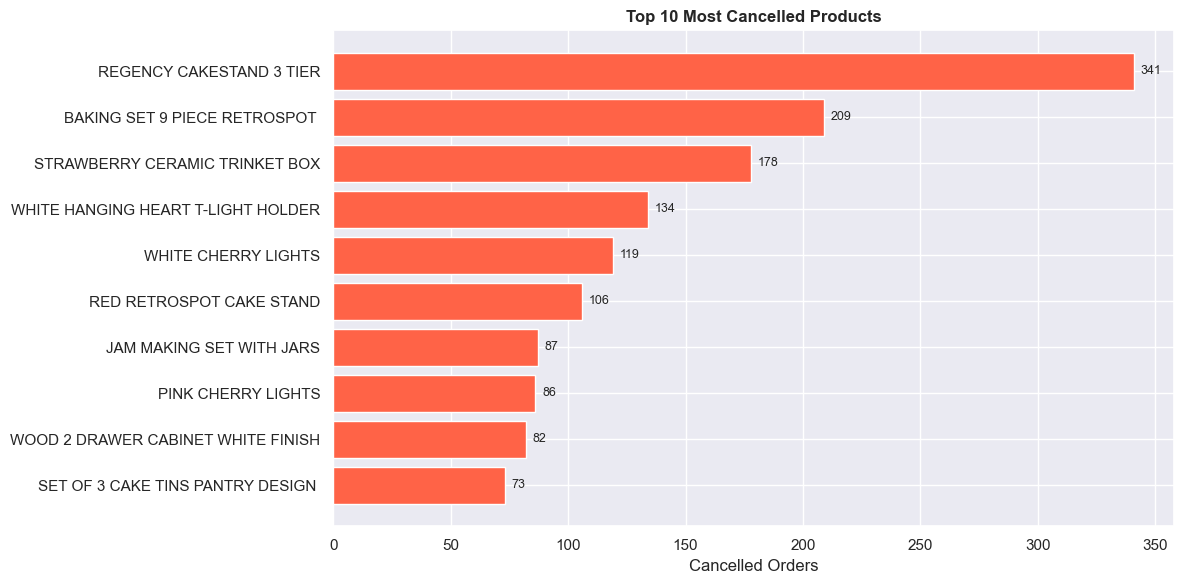


Top 10 Most Cancelled Products:
                       Description  Cancelled_Qty  Cancelled_Orders  Cancelled_Revenue
          REGENCY CAKESTAND 3 TIER           1468               341           16749.60
     BAKING SET 9 PIECE RETROSPOT             863               209            4072.75
    STRAWBERRY CERAMIC TRINKET BOX            928               178            1077.73
WHITE HANGING HEART T-LIGHT HOLDER           3638               134            9389.65
               WHITE CHERRY LIGHTS           1072               119            6331.30
          RED RETROSPOT CAKE STAND            507               106            4405.25
          JAM MAKING SET WITH JARS            256                87            1051.04
                PINK CHERRY LIGHTS            693                86            4021.35
WOOD 2 DRAWER CABINET WHITE FINISH            287                82            1704.65
 SET OF 3 CAKE TINS PANTRY DESIGN             157                73             744.95


In [47]:
# Top 10 produk dicancel
cancelled_products = df_cancelled.groupby(['StockCode', 'Description']).agg(
    Cancelled_Qty      = ('Quantity', lambda x: x.abs().sum()),
    Cancelled_Orders   = ('Invoice', 'nunique'),
    Cancelled_Revenue  = ('TotalPrice', 'sum')
).reset_index().sort_values('Cancelled_Orders', ascending=False)

# Filter non-produk
cancelled_products = cancelled_products[
    (~cancelled_products['Description'].isin(non_products)) &
    (cancelled_products['StockCode'].str.match(r'^\d{5}'))
]

top10_cancelled = cancelled_products.head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10_cancelled['Description'],
               top10_cancelled['Cancelled_Orders'],
               color='tomato')
ax.bar_label(bars, fmt='{:.0f}', padding=5, fontsize=9)
ax.set_title('Top 10 Most Cancelled Products', fontweight='bold')
ax.set_xlabel('Cancelled Orders')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/20_top_cancelled_products.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 Most Cancelled Products:")
print(top10_cancelled[['Description', 'Cancelled_Qty',
                        'Cancelled_Orders', 'Cancelled_Revenue'
                        ]].to_string(index=False))

In [ ]:
# Simpan oitput cancellation analysis
monthly_cancel.to_csv('../data/cleaned/monthly_cancellation.csv', index=False)
country_cancel.to_csv('../data/cleaned/cancellation_by_country.csv', index=False)
cancelled_products.to_csv('../data/cleaned/cancelled_products.csv', index=False)

print("monthly_cancellation.csv berhasil disimpan.")
print("cancellation_by_country.csv berhasil disimpan.")
print("cancelled_products.csv berhasil disimpan.")

✅ monthly_cancellation.csv berhasil disimpan!
✅ cancellation_by_country.csv berhasil disimpan!
✅ cancelled_products.csv berhasil disimpan!
